In [1]:
import pandas as pd

data = pd.read_parquet("data/block1_train.parquet", engine='fastparquet')

In [3]:
data.isna().sum()

quote_id                           0
vehicle_ownership_duration     22575
vehicle_number_plate               0
coverage                           0
claim_free_years                   0
                               ...  
Insurer_G_price               227071
Insurer_H_price               427889
Insurer_I_price               251863
Insurer_J_price               235193
Insurer_K_price               183605
Length: 155, dtype: int64

In [4]:
target_cols = [f"Insurer_{chr(i)}_price" for i in range(ord('A'), ord('K') + 1)]

In [5]:
data[target_cols].isna().sum()

Insurer_A_price     13920
Insurer_B_price    105533
Insurer_C_price    110281
Insurer_D_price    138213
Insurer_E_price    138736
Insurer_F_price    183448
Insurer_G_price    227071
Insurer_H_price    427889
Insurer_I_price    251863
Insurer_J_price    235193
Insurer_K_price    183605
dtype: int64

In [6]:
insurer_price_cols = [c for c in data.columns if 'Insurer_' in c and 'price' in c.lower()]
insurer_deduct_cols = [c for c in data.columns if 'Insurer_' in c and 'deduct' in c.lower()]
other_cols = [c for c in data.columns if 'Insurer_' not in c]

# Missing za cene osiguravača
print("=" * 80)
print("🏢 INSURER PRICE kolone (missing = odbijene ponude)")
print("=" * 80)
price_missing = data[insurer_price_cols].isnull().sum().sort_values(ascending=False)
for col, miss in price_missing.items():
    pct = (miss / len(data)) * 100
    print(f"{col:25} -> {miss:8,} missing ({pct:5.1f}%)")

# Missing za deductible osiguravača
print("\n" + "=" * 80)
print("🔧 INSURER DEDUCTIBLE kolone")
print("=" * 80)
deduct_missing = data[insurer_deduct_cols].isnull().sum().sort_values(ascending=False)
for col, miss in deduct_missing.items():
    pct = (miss / len(data)) * 100
    print(f"{col:25} -> {miss:8,} missing ({pct:5.1f}%)")

# Missing za ostale kolone
print("\n" + "=" * 80)
print("📋 OSTALE KOLONE")
print("=" * 80)
other_missing = data[other_cols].isnull().sum().sort_values(ascending=False)
for col, miss in other_missing.items():
    if miss > 0:
        pct = (miss / len(data)) * 100
        print(f"{col:35} -> {miss:8,} missing ({pct:5.1f}%)")

🏢 INSURER PRICE kolone (missing = odbijene ponude)
Insurer_H_price           ->  427,889 missing ( 79.0%)
Insurer_I_price           ->  251,863 missing ( 46.5%)
Insurer_J_price           ->  235,193 missing ( 43.5%)
Insurer_G_price           ->  227,071 missing ( 41.9%)
Insurer_K_price           ->  183,605 missing ( 33.9%)
Insurer_F_price           ->  183,448 missing ( 33.9%)
Insurer_E_price           ->  138,736 missing ( 25.6%)
Insurer_D_price           ->  138,213 missing ( 25.5%)
Insurer_C_price           ->  110,281 missing ( 20.4%)
Insurer_B_price           ->  105,533 missing ( 19.5%)
Insurer_A_price           ->   13,920 missing (  2.6%)

🔧 INSURER DEDUCTIBLE kolone
Insurer_H_deductible      ->  427,889 missing ( 79.0%)
Insurer_I_deductible      ->  251,863 missing ( 46.5%)
Insurer_J_deductible      ->  235,193 missing ( 43.5%)
Insurer_G_deductible      ->  227,071 missing ( 41.9%)
Insurer_K_deductible      ->  183,605 missing ( 33.9%)
Insurer_F_deductible      ->  183,448 mi

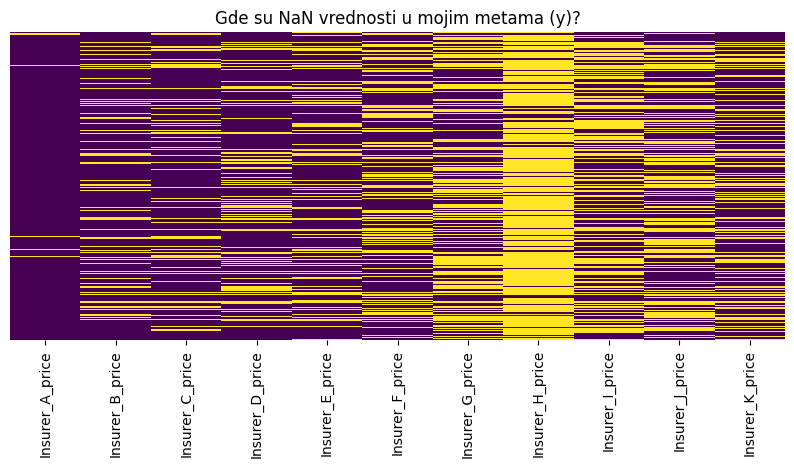

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vizuelizuj gde su rupe u y kolonama
plt.figure(figsize=(10, 4))
sns.heatmap(data[target_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Gde su NaN vrednosti u mojim metama (y)?")
plt.show()

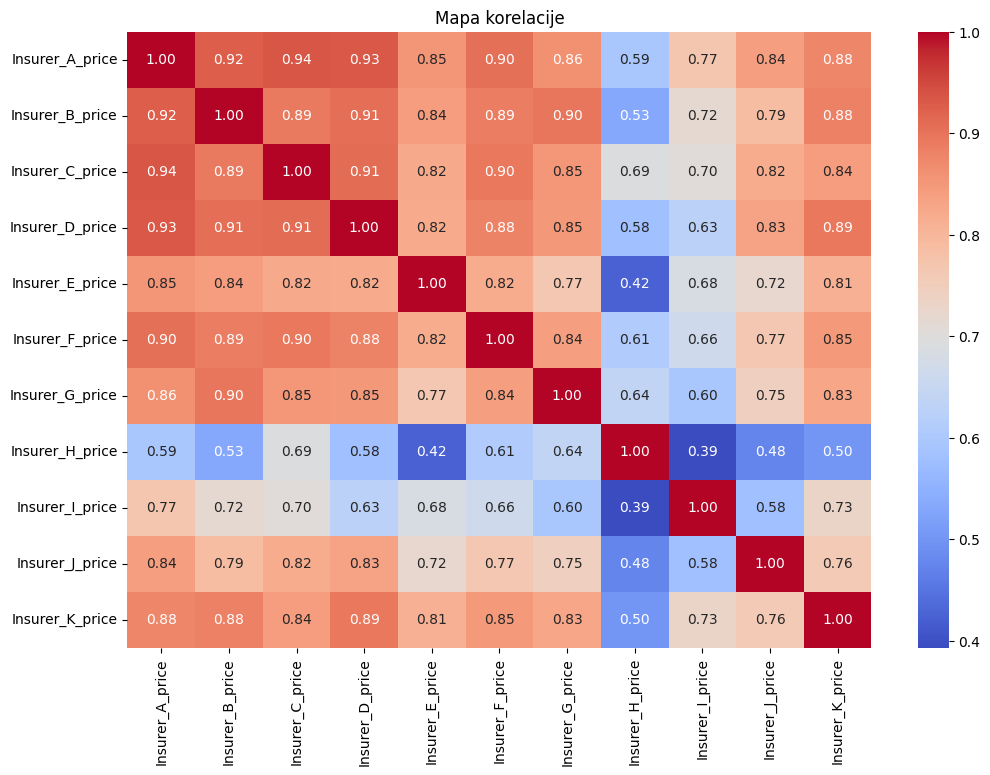

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Izračunaj korelaciju (samo za numeričke kolone)
corr = data[target_cols].corr(numeric_only=True)

# 2. Nacrtaj mapu
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Mapa korelacije')
plt.show()

In [11]:
def count_missing_A_not_B(df, col_A, col_B):
    return ((df[col_A].isna()) & (df[col_B].notna())).sum()

count_missing_A_not_B(data[target_cols], "Insurer_A_price", "Insurer_B_price")

np.int64(11532)

In [16]:
data_testing = pd.read_parquet("data/block2_test.parquet", engine='fastparquet')

data_testing.isna().sum()

quote_id                           0
vehicle_ownership_duration      6855
vehicle_number_plate               0
coverage                           0
claim_free_years                   0
                               ...  
Insurer_G_deductible           80762
Insurer_H_deductible          127372
Insurer_I_deductible           75565
Insurer_J_deductible           77214
Insurer_K_deductible           58874
Length: 144, dtype: int64

In [17]:
deductible_cols = [f"Insurer_{chr(i)}_deductible" for i in range(ord('A'), ord('K') + 1)]
data_testing[deductible_cols].isna().sum()

Insurer_A_deductible      4554
Insurer_B_deductible     27955
Insurer_C_deductible     30832
Insurer_D_deductible     35064
Insurer_E_deductible     38868
Insurer_F_deductible     61612
Insurer_G_deductible     80762
Insurer_H_deductible    127372
Insurer_I_deductible     75565
Insurer_J_deductible     77214
Insurer_K_deductible     58874
dtype: int64

In [ ]:
# napravimo listu deductible kolona
deductible_cols = [f"Insurer_{chr(i)}_deductible" for i in range(ord('A'), ord('K') + 1)]

for i in range(len(deductible_cols)):
    

Broj redova gde sve fali: 547


In [ ]:
# proveravamo po koloni
for d_col, y_col in zip(deductible_cols, target_cols):
    mask_d_nan = data[d_col].isna()

    num_target_nan = data.loc[mask_d_nan, y_col].isna().sum()
    total_d_nan = mask_d_nan.sum()
    
    print(f"{d_col} → ukupno deductible NaN: {total_d_nan}, od toga price NaN: {num_target_nan}")
    if num_target_nan == total_d_nan:
        print("✅ Uvek kada je deductible NaN, target je takođe NaN")
    else:
        print(f"⚠️ Postoje {total_d_nan - num_target_nan} redova gde je deductible NaN, ali target nije NaN")

Insurer_A_deductible → ukupno deductible NaN: 13920, od toga price NaN: 13920
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_B_deductible → ukupno deductible NaN: 105533, od toga price NaN: 105533
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_C_deductible → ukupno deductible NaN: 110281, od toga price NaN: 110281
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_D_deductible → ukupno deductible NaN: 138213, od toga price NaN: 138213
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_E_deductible → ukupno deductible NaN: 138736, od toga price NaN: 138736
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_F_deductible → ukupno deductible NaN: 183448, od toga price NaN: 183448
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_G_deductible → ukupno deductible NaN: 227071, od toga price NaN: 227071
✅ Uvek kada je deductible NaN, target je takođe NaN
Insurer_H_deductible → ukupno deductible NaN: 427889, od toga price NaN: 42788

In [33]:
data[target_cols].isna().sum()

Insurer_A_price     13920
Insurer_B_price    105533
Insurer_C_price    110281
Insurer_D_price    138213
Insurer_E_price    138736
Insurer_F_price    183448
Insurer_G_price    227071
Insurer_H_price    427889
Insurer_I_price    251863
Insurer_J_price    235193
Insurer_K_price    183605
dtype: int64

In [37]:
df_clean = data_testing.dropna(subset=deductible_cols, how='all')

print(f"Originalni broj redova: {len(data_testing)}")
print(f"Broj redova nakon čišćenja: {len(df_clean)}")

Originalni broj redova: 164092
Broj redova nakon čišćenja: 163545


In [38]:
data[target_cols].describe()

,Insurer_A_price,Insurer_B_price,Insurer_C_price,Insurer_D_price,Insurer_E_price,Insurer_F_price,Insurer_G_price,Insurer_H_price,Insurer_I_price,Insurer_J_price,Insurer_K_price
count,527372.000000,435759.000000,431011.000000,403079.000000,402556.000000,357844.000000,314221.000000,113403.000000,289429.000000,306099.000000,357687.000000
mean,96.892238,99.776924,89.317435,98.455883,115.724284,97.402689,84.512742,116.088805,94.852855,104.652815,124.022612
std,115.546544,75.546169,62.876261,71.323409,88.181914,66.100947,51.646574,75.962520,71.100297,74.233062,83.572330
min,12.330800,15.750000,12.160000,14.010000,15.550000,14.110000,12.480000,15.200000,14.050000,16.030000,15.710000
25%,44.878300,51.490000,48.540000,51.100000,61.560000,53.170000,49.260000,62.090000,49.380000,55.580000,65.610000
50%,67.802500,76.340000,70.840000,75.830000,90.290000,79.130000,70.350000,92.440000,70.010000,82.200000,97.140000
75%,111.719200,120.550000,108.530000,121.240000,139.660000,121.640000,103.750000,149.350000,113.840000,128.480000,159.420000
max,4370.410000,1252.460000,1095.150000,858.630000,2283.810000,781.350000,646.480000,995.960000,901.980000,1451.770000,1335.960000


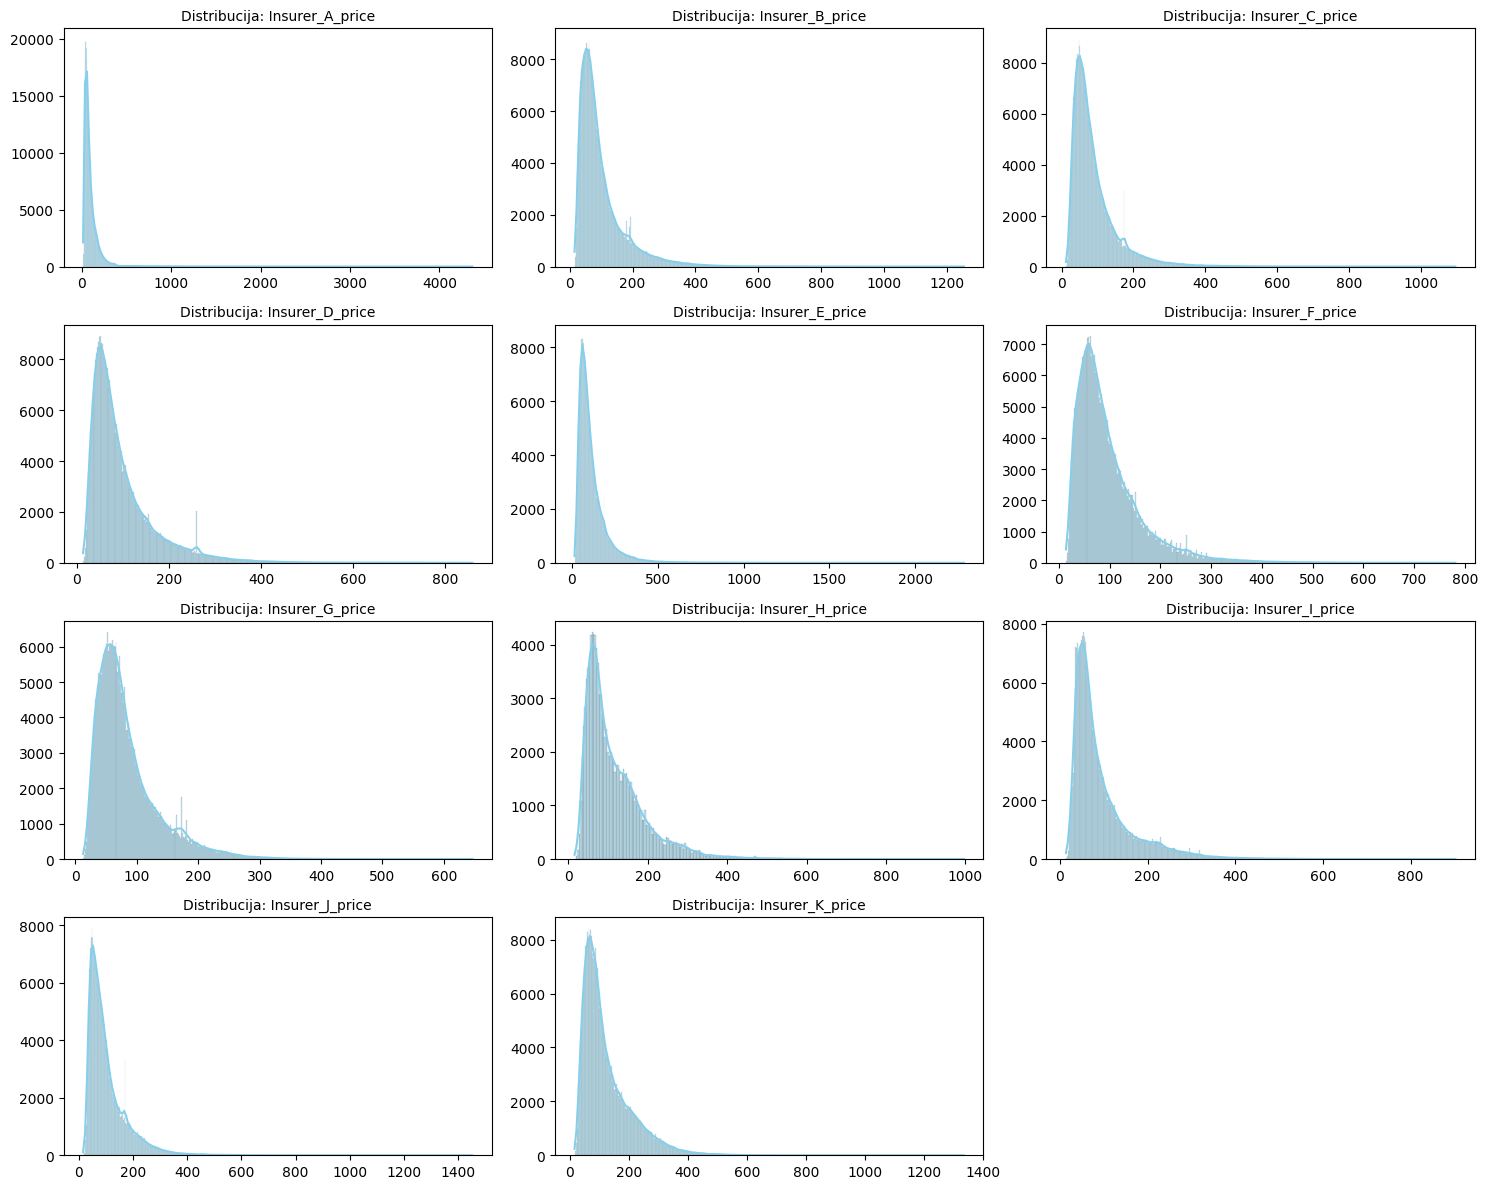

In [41]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten() # Pretvaramo matricu u niz radi lakše petlje

for i, col in enumerate(target_cols):
    # Crta histogram + KDE (liniju trenda)
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribucija: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Brišemo prazne grafikone ako ih ima (npr. 12. polje ako imaš 11 kolona)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [49]:
df_a = data[data['Insurer_A_price'].notnull()].copy()

df_a = df_a.dropna(axis=1, how='all')

In [ ]:
import numpy as np

target = 'Insurer_A_price'


features = [col for col in df_a.columns if col not in target_cols and col not in deductible_cols ]
features.append('Insurer_A_deductible')
X = df_a[features]
y = np.log1p(df_a[target]) # log

In [84]:
cat_features = list(X.select_dtypes(include=['object', 'category']).columns)
print(f"Kategorijalne kolone: {cat_features}")

Kategorijalne kolone: ['vehicle_ownership_duration', 'vehicle_number_plate', 'coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'is_driver_owner', 'usage', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_primary_color', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'vehicle_last_registration_date', 'vehicle_years_since_country_first_registration', 'vehicle_inspection_report_date', 'vehicle_inspection_expiry_date', 'vehicle_inspection_number_of_deficiencies_found', 'vehicle_year_of_last_odometer_re

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [77]:
len(cat_features)

129

In [78]:
def high_sparsity_columns(df, cat_cols, threshold=10):
    high_sparsity = [col for col in cat_cols if df[col].nunique() > threshold]
    return high_sparsity

In [82]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

def encode_categorical(train, test, cat_cols, high_sparsity_threshold=10):
    """
    Enkodira kategorijske kolone:
    - High sparsity (> threshold) -> OrdinalEncoder
    - Low sparsity (<= threshold) -> OneHotEncoder
    
    Parameters:
        train (pd.DataFrame): Train dataset
        test (pd.DataFrame): Test dataset
        cat_cols (list): Lista svih kategorijskih kolona
        high_sparsity_threshold (int): Granica iznad koje kolona ide na ordinal
    
    Returns:
        train_enc, test_enc: Transformisani train i test DataFrame-ovi
    """
    train_enc = train.copy()
    test_enc = test.copy()
    
    high_sparse_cols = [c for c in cat_cols if train[c].nunique() > high_sparsity_threshold]
    low_sparse_cols = [c for c in cat_cols if train[c].nunique() <= high_sparsity_threshold]
    
    # Ordinal encoding za high sparsity
    if high_sparse_cols:
        oe = OrdinalEncoder()
        train_enc[high_sparse_cols] = oe.fit_transform(train[high_sparse_cols])
        test_enc[high_sparse_cols] = oe.transform(test[high_sparse_cols])
    
    # One-hot encoding za low sparsity
    if low_sparse_cols:
        ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
        train_ohe = ohe.fit_transform(train[low_sparse_cols])
        test_ohe = ohe.transform(test[low_sparse_cols])
        
        # Napravimo kolone sa imenima
        ohe_cols = ohe.get_feature_names_out(low_sparse_cols)
        train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=train.index)
        test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_cols, index=test.index)
        
        # Drop original low sparsity cols i dodaj one-hot
        train_enc = train_enc.drop(columns=low_sparse_cols).join(train_ohe_df)
        test_enc = test_enc.drop(columns=low_sparse_cols).join(test_ohe_df)
    
    return train_enc, test_enc

In [85]:
X_train_encoded, X_test_encoded = encode_categorical(X_train, X_test,cat_features )

ValueError: Found unknown categories ['f9c02b6c13', '176a1227eb', 'a9fb28424c', '0c6ce3ad33', '991a4e7c02', 'fa2a3037c6', 'c3392f88de', 'ce2b1b828f', '2649863bd4', '824043bd35', '933d2616a9', 'e034f2c5ff', '2da7252142', '61a94d17e7', 'e932c23310', 'dbe0bc0b44', '0d523e0803', '9425f79c89', '200b7d14cb', 'c88a9b4b88', '37223abe41', 'b307f8f311', '41415fa2c6', '6055ac34b5', 'd960a2208b', 'c5601bde93', 'a26d8f3b5e', 'b4c0dcc742', 'ccb564cb40', 'f7bb994aba', '22509f6eea', '349670c0ee', '219e9a0b4b', '2b44431c1e', '17a6c31f39', 'a8c59cdc1f', '438bfcd7be', 'b2e38c4e3b', '95eaa315c2', 'be4a3d638d', 'd3b4987e01', '2a78648d5c', '6326945cf6', '2b71b46e10', '1997f99ed3', 'b2df8a83a4', '7f634a23b1', '01de139674', '1aa5d959a8', 'b6973389b6', '38ac1028c6', 'e4469b8a85', '0751205881', 'f3b6ed9540', 'c94e872dfc', '60fd27438f', '98ab75e2f4', '222e605e42', '5e60eb6766', 'ed84bfc86d', '8048551201', '4a286c2f0f', '4e2395389d', 'd689471595', '4ec3c87f5a', 'afadf3721e', '44e5ab519f', 'c9e2187b1a', 'af68ea1fb

In [86]:
cat_features

['vehicle_ownership_duration',
 'vehicle_number_plate',
 'coverage',
 'claim_free_years',
 'payment_frequency',
 'contractor_birthdate',
 'is_driver_owner',
 'usage',
 'vehicle_maker',
 'vehicle_model',
 'vehicle_fuel_type',
 'vehicle_engine_size',
 'vehicle_power',
 'vehicle_net_weight',
 'vehicle_gross_weight',
 'vehicle_length',
 'vehicle_width',
 'vehicle_height',
 'vehicle_number_of_cylinders',
 'vehicle_number_of_doors',
 'vehicle_number_of_seats',
 'vehicle_number_of_wheels',
 'vehicle_primary_color',
 'vehicle_value_new',
 'vehicle_net_max_power',
 'vehicle_net_max_power_electric',
 'vehicle_nominal_continuous_max_power',
 'vehicle_power_to_net_weight_ratio',
 'vehicle_age',
 'vehicle_first_registration_date',
 'vehicle_country_first_registration_date',
 'vehicle_last_registration_date',
 'vehicle_years_since_country_first_registration',
 'vehicle_inspection_report_date',
 'vehicle_inspection_expiry_date',
 'vehicle_inspection_number_of_deficiencies_found',
 'vehicle_year_of_la